# Penugasan Machine Learning EDM G6: Sales Prediction & Customer Segmentation
Nama: Maya Radina Putri

Analisis ini bertujuan untuk memahami pola penjualan produk cokelat berdasarkan dataset penjualan yang tersedia.
Output yang dihasilkan dalam analisis ini adalah:
1. Sales Prediction (Regresi): Memprediksi revenue (pendapatan) penjualan.
2. Customer Segmentation (Clustering): Mengelompokkan pola transaksi pelanggan.

Tahapan dilakukan mulai dari Data Understanding, Data Preprocessing, Exploratory Data Analysis, Modelling, hingga Evaluation.

# Import Library


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans


Pada tahap ini dilakukan import beberapa library yang akan digunakan selama proses analisis data dan pembuatan model machine learning. Library pandas digunakan untuk membaca dan mengolah dataset dalam bentuk tabel, sedangkan numpy digunakan untuk melakukan operasi numerik, matplotlib & seaborn untuk grafik, dan sklearn untuk Machine Learning (regresi dan clustering)

# Load Dataset


In [19]:
df = pd.read_csv("chocolate_sales_2025_dataset.csv")
display(df.head())


,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


Dataset Chocolate Sales 2025 dimuat menggunakan fungsi read_csv() dari pandas. Dataset ini berisi data transaksi penjualan cokelat pada tahun 2025 dengan beberapa atribut seperti brand produk, tipe produk, negara penjualan, channel penjualan, metode pembayaran, harga produk, jumlah unit yang terjual, serta total revenue.

Fungsi head() digunakan untuk menampilkan beberapa baris pertama dari dataset sehingga struktur data dapat terlihat dengan jelas sebelum dilakukan proses analisis lebih lanjut.

# 1. Data Understanding

In [20]:
print("\nInformasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


Perintah df.info() digunakan untuk menampilkan informasi ringkas mengenai dataset, seperti total baris, nama-nama kolom, tipe data setiap kolom (apakah berupa teks atau angka), serta mendeteksi ada atau tidaknya nilai kosong (null/missing values).

In [23]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,13.779860,104.938000,1433.391140
std,144.481833,6.484013,56.263998,1065.679386
min,1.000000,2.520000,5.000000,20.480000
25%,125.750000,8.592500,56.750000,562.545000
50%,250.500000,13.480000,108.500000,1197.225000
75%,375.250000,19.445000,150.250000,2072.812500
max,500.000000,25.000000,200.000000,4809.260000


Perintah df.describe() digunakan untuk menampilkan statistik deskriptif dari kolom numerik. Informasi yang disajikan meliputi nilai rata-rata (mean), standar deviasi, nilai minimum, kuartil, hingga nilai maksimum. Hal ini penting untuk melihat distribusi data dan mendeteksi anomali (outliers).

In [ ]:
df.isnull().sum()

Perintah df.isnull().sum() digunakan untuk menghitung jumlah nilai kosong atau missing values pada setiap kolom dalam dataset. Dengan menggunakan perintah ini, kita dapat mengetahui kolom mana saja yang memiliki data yang hilang sehingga dapat menentukan langkah selanjutnya dalam proses pembersihan data.

#2. Exploratory Data Analysis (EDA)



Lineplot – Revenue Trend



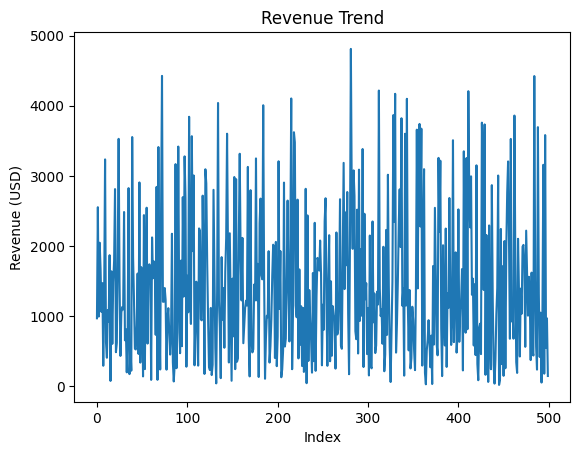

In [31]:
sns.lineplot(x=df.index, y=df["Revenue_USD"])
plt.title("Revenue Trend")
plt.xlabel("Index")
plt.ylabel("Revenue (USD)")
plt.show()

Grafik lineplot menunjukkan perubahan nilai revenue dalam dataset berdasarkan urutan data. Dari grafik ini dapat diamati bahwa nilai revenue memiliki variasi yang cukup besar pada setiap transaksi. Hal ini menunjukkan bahwa jumlah pendapatan dari penjualan cokelat tidak selalu stabil dan dipengaruhi oleh beberapa faktor seperti harga produk dan jumlah unit yang terjual.

Countplot – Brand Distribution

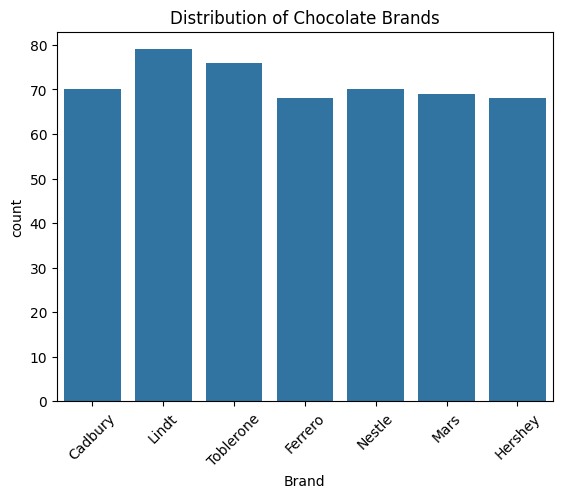

In [32]:
sns.countplot(x=df["Brand"])
plt.title("Distribution of Chocolate Brands")
plt.xticks(rotation=45)
plt.show()

Grafik countplot menunjukkan distribusi jumlah data berdasarkan merek cokelat yang terdapat dalam dataset. Dari grafik ini dapat terlihat merek mana yang paling sering muncul dalam transaksi penjualan. Merek dengan jumlah data terbanyak menunjukkan bahwa produk tersebut lebih sering tercatat dalam dataset dibandingkan merek lainnya.

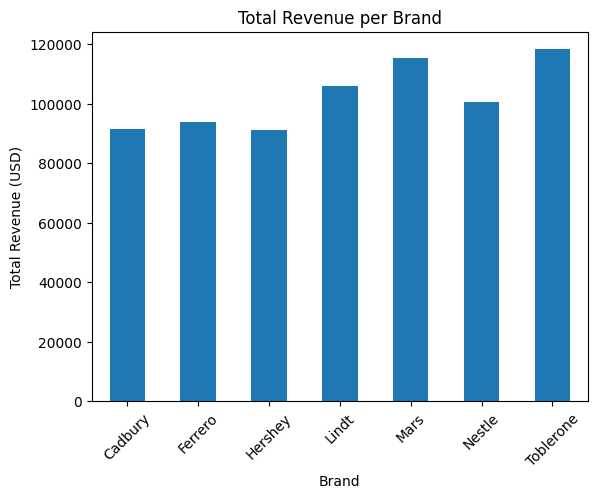

In [44]:
brand_revenue = df.groupby("Brand")["Revenue_USD"].sum()

brand_revenue.plot(kind="bar")
plt.title("Total Revenue per Brand")
plt.xlabel("Brand")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45)
plt.show()

Grafik batang ini menunjukkan total revenue yang dihasilkan oleh setiap brand cokelat. Data dikelompokkan berdasarkan brand menggunakan fungsi groupby(), kemudian total revenue dihitung menggunakan fungsi sum().

Dari grafik ini dapat dilihat brand mana yang memberikan kontribusi pendapatan terbesar dalam dataset penjualan cokelat.

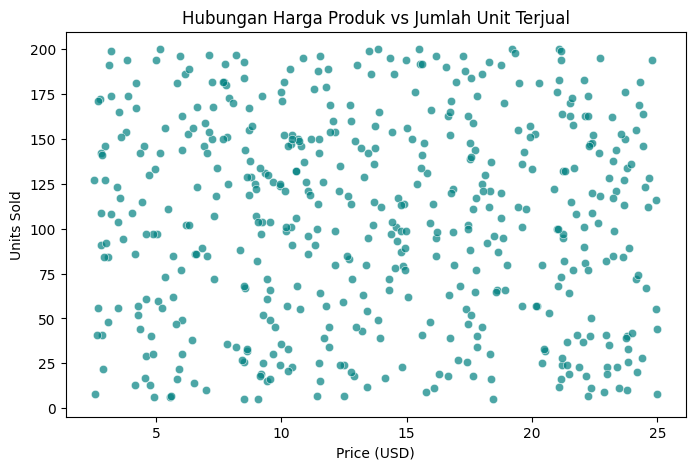

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Price_USD', y='Units_Sold', data=df, color='teal', alpha=0.7)
plt.title("Hubungan Harga Produk vs Jumlah Unit Terjual")
plt.xlabel("Price (USD)")
plt.ylabel("Units Sold")
plt.show()

Perintah sns.scatterplot() digunakan untuk membuat grafik titik (scatter) guna melihat korelasi antara dua variabel numerik, yaitu harga produk (Price_USD) pada sumbu X dan jumlah unit yang terjual (Units_Sold) pada sumbu Y. Hal ini penting untuk melihat pola apakah harga tinggi menyebabkan penurunan jumlah barang yang dibeli.

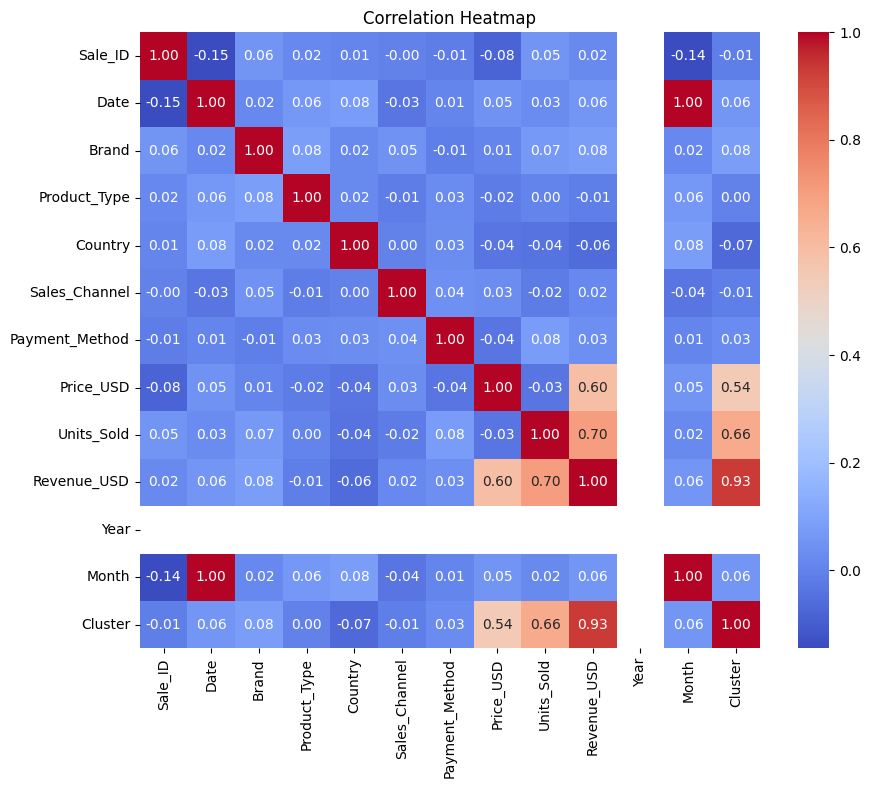

In [71]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

Perintah ini digunakan untuk menampilkan heatmap korelasi antar variabel numerik dalam dataset. Warna pada heatmap menunjukkan kekuatan hubungan antar variabel, di mana warna merah menunjukkan korelasi positif yang kuat dan warna biru menunjukkan korelasi yang lebih lemah atau negatif. Angka di dalam kotak menunjukkan nilai korelasi antar variabel.

# 3. Data Processing

In [45]:
df = df.dropna()

Perintah dropna() digunakan untuk menghapus baris data yang memiliki nilai kosong. Proses ini dilakukan untuk memastikan bahwa dataset yang digunakan dalam proses analisis dan pemodelan machine learning tidak mengandung missing values yang dapat mempengaruhi hasil model

In [46]:
df["Date"] = pd.to_datetime(df["Date"])

Perintah ini digunakan untuk mengubah tipe data pada kolom Date menjadi format datetime. Konversi ini penting dilakukan agar informasi tanggal dapat diproses dengan lebih baik dalam analisis data maupun dalam pembuatan fitur tambahan yang berkaitan dengan waktu.

In [47]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

Perintah ini digunakan untuk mengekstrak informasi tahun dan bulan dari kolom tanggal. Informasi waktu seperti tahun dan bulan dapat membantu model machine learning dalam mengenali pola penjualan yang mungkin dipengaruhi oleh waktu tertentu

In [48]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

cat_cols = [
    "Brand",
    "Product_Type",
    "Country",
    "Sales_Channel",
    "Payment_Method"
]

for column in cat_cols:
    df[column] = encoder.fit_transform(df[column])

Kode di atas digunakan untuk melakukan proses encoding pada variabel kategorikal dalam dataset. Library LabelEncoder dari scikit-learn digunakan untuk mengubah data kategori menjadi nilai numerik. Hal ini diperlukan karena sebagian besar algoritma machine learning hanya dapat memproses data dalam bentuk angka.

Pertama, dibuat objek encoder menggunakan LabelEncoder(). Kemudian didefinisikan daftar kolom yang memiliki tipe data kategorikal seperti brand, jenis produk, negara, channel penjualan, dan metode pembayaran. Selanjutnya dilakukan perulangan pada setiap kolom tersebut untuk mengubah nilai kategori menjadi angka menggunakan fungsi fit_transform() sehingga data siap digunakan pada tahap pemodelan machine learning.

#4. Modelling

# Regression (Sales **Prediction**

In [49]:
X = df[['Price_USD','Units_Sold','Brand','Product_Type','Country','Sales_Channel','Payment_Method','Year','Month']]
y = df['Revenue_USD']

Pada tahap ini dilakukan pemisahan antara variabel fitur dan variabel target.

Variabel X berisi faktor-faktor yang mempengaruhi penjualan seperti harga, jumlah unit terjual, brand, jenis produk, negara, channel penjualan, metode pembayaran, serta informasi waktu.

Sedangkan variabel y merupakan target yang ingin diprediksi yaitu revenue penjualan.

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dataset dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model machine learning, sedangkan data testing digunakan untuk mengevaluasi performa model.

In [51]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Model Linear Regression digunakan untuk mempelajari hubungan antara variabel input dengan revenue penjualan. Model dilatih menggunakan data training agar dapat mengenali pola yang terdapat dalam dataset.

In [52]:
y_pred = model.predict(X_test)

Setelah model selesai dilatih, model digunakan untuk melakukan prediksi revenue pada data testing.

Hasil prediksi ini kemudian dibandingkan dengan nilai revenue sebenarnya untuk melihat seberapa baik model dapat memprediksi nilai revenue berdasarkan fitur yang tersedia.

## 5. Evaluation Regression

In [53]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 299.88028062331466
R2 Score: 0.8680848253033006


Performa model dievaluasi menggunakan dua metrik yaitu Mean Absolute Error (MAE) dan R² Score.

MAE digunakan untuk melihat rata-rata selisih antara nilai prediksi dan nilai sebenarnya, sedangkan R² Score menunjukkan seberapa besar variasi dalam data yang dapat dijelaskan oleh model.

Nilai evaluasi ini memberikan gambaran mengenai seberapa baik model Linear Regression dalam memprediksi revenue pada dataset Chocolate Sales 2025.

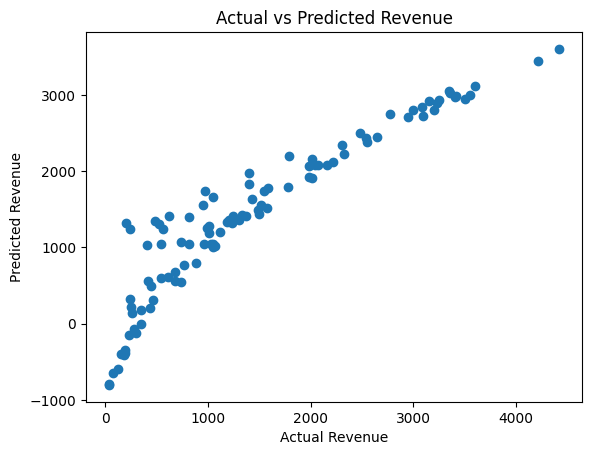

In [54]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

Scatter plot digunakan untuk membandingkan nilai revenue sebenarnya dengan nilai revenue hasil prediksi model. Jika titik-titik berada mendekati garis diagonal, maka model memiliki performa prediksi yang baik.

# Customer Segmentation (Clustering)

In [62]:
X_cluster = df[['Units_Sold','Revenue_USD','Price_USD']]

Kode ini digunakan untuk memilih fitur yang akan digunakan dalam proses clustering. Variabel yang dipilih adalah jumlah unit terjual, revenue penjualan, dan harga produk karena ketiga variabel tersebut dapat membantu menggambarkan karakteristik penjualan yang berbeda.

In [67]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

Selanjutnya dilakukan proses Elbow Method dengan mencoba beberapa jumlah cluster yang berbeda. Untuk setiap jumlah cluster, model K-Means dilatih menggunakan data yang telah dipilih dan nilai inertia disimpan.

Nilai inertia tersebut kemudian digunakan untuk membuat grafik Elbow Method yang membantu menentukan jumlah cluster yang paling optimal berdasarkan titik dimana penurunan grafik mulai melambat..

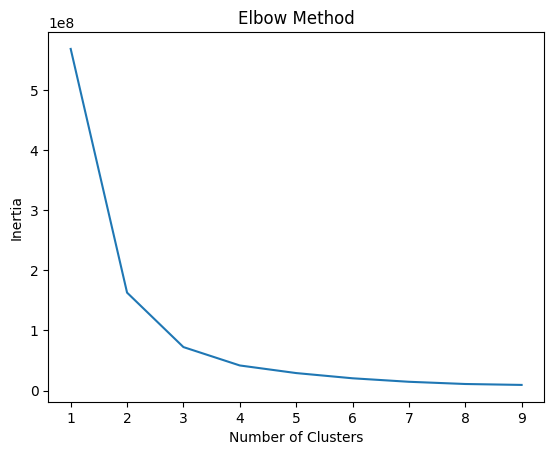

In [64]:
plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Grafik ini menampilkan hasil Elbow Method, yaitu hubungan antara jumlah cluster dan nilai inertia.

 Titik dimana grafik mulai melandai disebut sebagai elbow point, yang biasanya dipilih sebagai jumlah cluster optimal karena penambahan cluster setelah titik tersebut tidak memberikan peningkatan yang signifikan.

In [68]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

Setelah jumlah cluster optimal ditentukan, algoritma K-Means digunakan untuk mengelompokkan data ke dalam tiga cluster. Setiap data akan diberi label cluster yang menunjukkan kelompoknya.

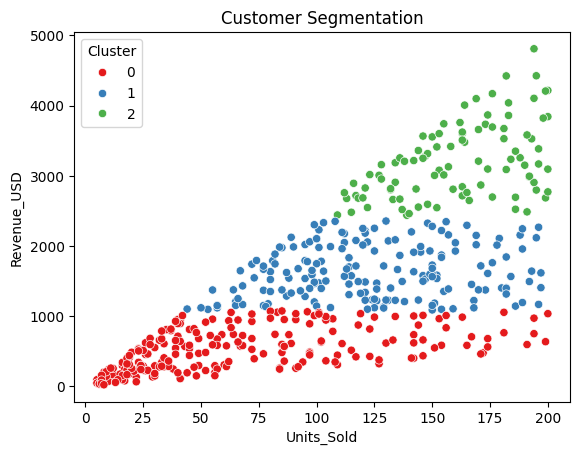

In [69]:
sns.scatterplot(
    x='Units_Sold',
    y='Revenue_USD',
    hue='Cluster',
    data=df,
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

Scatter plot ini digunakan untuk memvisualisasikan hasil clustering. Setiap warna pada grafik menunjukkan cluster yang berbeda sehingga dapat terlihat bagaimana data penjualan terbagi ke dalam beberapa kelompok berdasarkan karakteristiknya.

# Kesimpulan
Berdasarkan analisis yang dilakukan, proses dimulai dengan memahami struktur dataset serta melakukan visualisasi untuk melihat pola dan hubungan antar variabel.

Selanjutnya dilakukan data processing seperti menangani missing value, mengolah fitur tanggal, dan mengubah data kategorikal menjadi numerik menggunakan encoding.

 Model regresi digunakan untuk memprediksi Revenue_USD, sedangkan metode K-Means clustering digunakan untuk mengelompokkan data penjualan berdasarkan karakteristiknya.

 Hasil analisis menunjukkan bahwa Units_Sold memiliki hubungan yang cukup kuat terhadap Revenue_USD, sehingga jumlah unit yang terjual menjadi salah satu faktor utama yang mempengaruhi revenue.